https://archive.ics.uci.edu/dataset/320/student+performance


In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
student_performance = fetch_ucirepo(id=320)

# data (as pandas dataframes)
X = student_performance.data.features
y = student_performance.data.targets





In [ ]:
y.head()

,G1,G2,G3
0,0,11,11
1,9,11,11
2,12,13,12
3,14,14,14
4,11,13,13


In [ ]:
student_performance.variables

,name,role,type,demographic,description,units,missing_values
0,school,Feature,Categorical,None,student's school (binary: 'GP' - Gabriel Perei...,None,no
1,sex,Feature,Binary,Sex,student's sex (binary: 'F' - female or 'M' - m...,None,no
2,age,Feature,Integer,Age,student's age (numeric: from 15 to 22),None,no
3,address,Feature,Categorical,None,student's home address type (binary: 'U' - urb...,None,no
4,famsize,Feature,Categorical,Other,family size (binary: 'LE3' - less or equal to ...,None,no
5,Pstatus,Feature,Categorical,Other,parent's cohabitation status (binary: 'T' - li...,None,no
6,Medu,Feature,Integer,Education Level,"mother's education (numeric: 0 - none, 1 - pr...",None,no
7,Fedu,Feature,Integer,Education Level,"father's education (numeric: 0 - none, 1 - pr...",None,no
8,Mjob,Feature,Categorical,Occupation,"mother's job (nominal: 'teacher', 'health' car...",None,no
9,Fjob,Feature,Categorical,Occupation,"father's job (nominal: 'teacher', 'health' car...",None,no


In [ ]:
import pandas as pd
data = pd.concat([X, y], axis=1)
data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
numerical = X.select_dtypes(include=['int64','float64'])
categorical = X.select_dtypes(include=['object'])

In [ ]:
categorical.head()

,school,sex,address,famsize,Pstatus,Mjob,Fjob,reason,guardian,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic
0,GP,F,U,GT3,A,at_home,teacher,course,mother,yes,no,no,no,yes,yes,no,no
1,GP,F,U,GT3,T,at_home,other,course,father,no,yes,no,no,no,yes,yes,no
2,GP,F,U,LE3,T,at_home,other,other,mother,yes,no,no,no,yes,yes,yes,no
3,GP,F,U,GT3,T,health,services,home,mother,no,yes,no,yes,yes,yes,yes,yes
4,GP,F,U,GT3,T,other,other,home,father,no,yes,no,no,yes,yes,no,no


In [ ]:
cat_numerical = pd.get_dummies(categorical, drop_first=True)
cat_numerical.head()


,school_MS,sex_M,address_U,famsize_LE3,Pstatus_T,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,False,False,True,False,False,False,False,False,False,False,...,True,False,True,False,False,False,True,True,False,False
1,False,False,True,False,True,False,False,False,False,False,...,False,False,False,True,False,False,False,True,True,False
2,False,False,True,True,True,False,False,False,False,False,...,True,False,True,False,False,False,True,True,True,False
3,False,False,True,False,True,True,False,False,False,False,...,True,False,False,True,False,True,True,True,True,True
4,False,False,True,False,True,False,True,False,False,False,...,False,False,False,True,False,False,True,True,False,False


In [ ]:
X = pd.concat([numerical, cat_numerical], axis = 1)
X.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,0,4,3,2,2,...,True,False,True,False,False,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,False,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,False,False,True,True,False,False


In [ ]:
y = pd.get_dummies(y,drop_first=True)

In [ ]:
data = pd.concat([X, y], axis=1)

In [ ]:
data

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes,G1,G2,G3
0,18,4,4,2,2,0,4,3,4,1,...,False,False,False,True,True,False,False,0,11,11
1,17,1,1,1,2,0,5,3,3,1,...,True,False,False,False,True,True,False,9,11,11
2,15,1,1,1,2,0,4,3,2,2,...,False,False,False,True,True,True,False,12,13,12
3,15,4,2,1,3,0,3,2,2,1,...,True,False,True,True,True,True,True,14,14,14
4,16,3,3,1,2,0,4,3,2,1,...,True,False,False,True,True,False,False,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,19,2,3,1,3,1,5,4,2,1,...,False,False,True,False,True,True,False,10,11,10
645,18,3,1,1,2,0,4,3,4,1,...,True,False,False,True,True,True,False,15,15,16
646,18,1,1,2,2,0,1,1,1,1,...,False,False,True,True,True,False,False,11,12,9
647,17,3,1,2,1,0,2,4,5,3,...,False,False,False,False,True,True,False,10,10,10


In [ ]:
df = pd.DataFrame(data)

df.to_excel('output.xlsx', index=False)

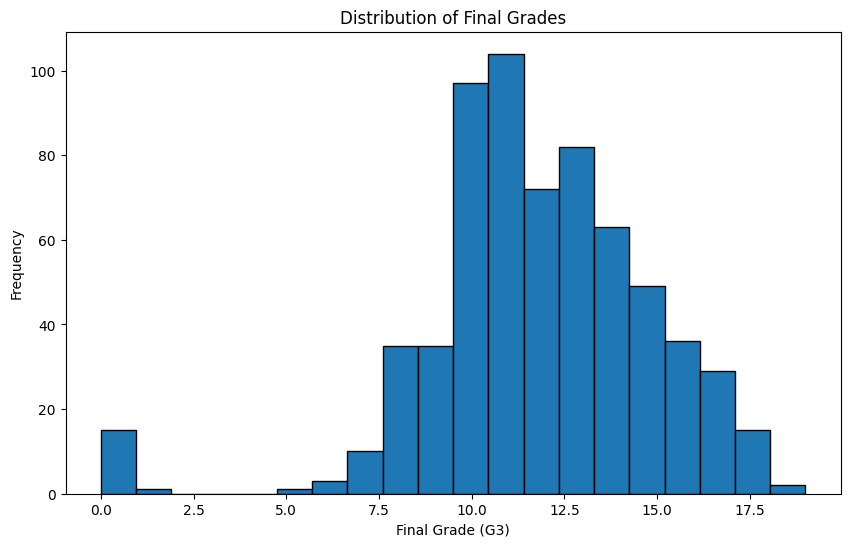

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.hist(data['G3'], bins=20, edgecolor='black')
plt.title("Distribution of Final Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Frequency")
plt.show()

Final Grades ranges from 0-20

The distribution of final grades (G3) shows that most students have grades concentrated in the middle range, with fewer students achieving extremely high or low scores.

I want to visually display the different factors that leads to student grade which can then lead us to draw conclusions.

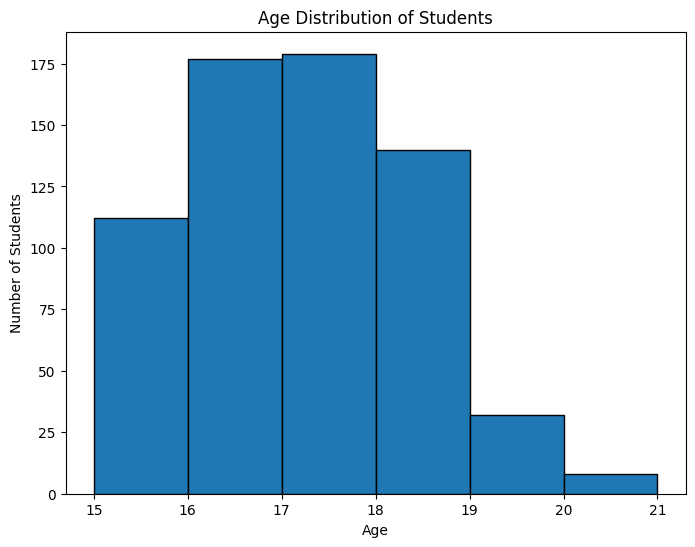

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(df['age'], bins=range(df['age'].min(), df['age'].max()), edgecolor='black')
plt.title('Age Distribution of Students')
plt.xlabel('Age')
plt.ylabel('Number of Students')
plt.show()

The histogram displays the distribution of student ages in the dataset. The data reveals that the majority of students are between 15 and 18 years old, with a peak around 16-17 years.

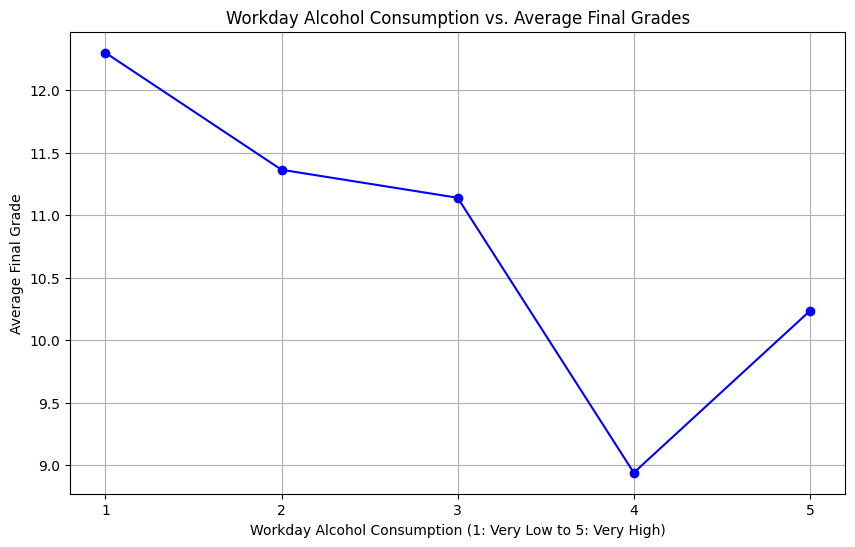

In [ ]:
#Groups the unique values in Dalc and finds the average final grade for each value
alcohol_avg_grades = data.groupby('Dalc')['G3'].mean()
plt.plot(alcohol_avg_grades.index, alcohol_avg_grades.values, marker='o', linestyle='-', color='blue')
plt.title("Workday Alcohol Consumption vs. Average Final Grades")
plt.xlabel("Workday Alcohol Consumption (1: Very Low to 5: Very High)")
plt.ylabel("Average Final Grade")
plt.xticks(ticks=range(1, 6))
plt.grid()
plt.show()

The line plot shows a downward trend in average final grades as workday alcohol consumption increases. This shows there is a negative impact and grades decrease with of higher consumption of alcohol.

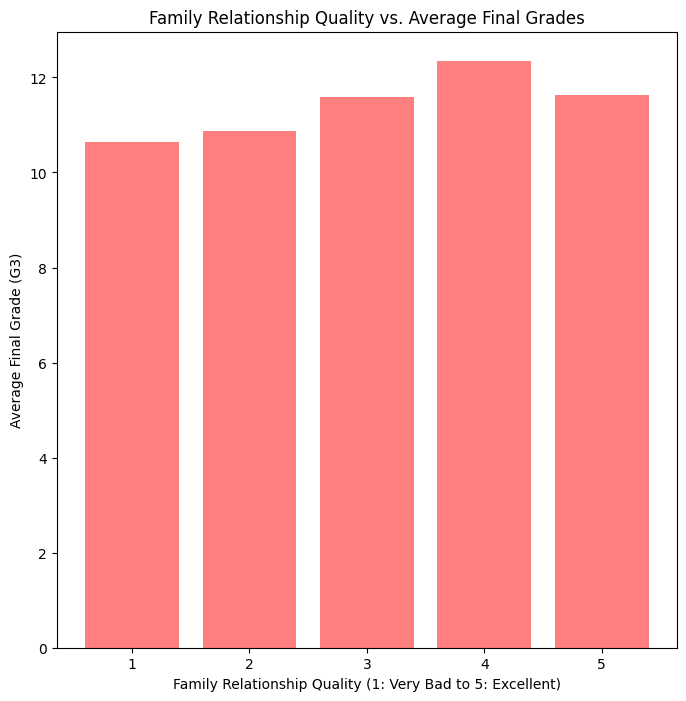

In [ ]:
plt.figure(figsize=(8, 8))
family_avg_grades = data.groupby('famrel')['G3'].mean()
plt.bar(family_avg_grades.index, family_avg_grades.values, color='red', alpha = .5)
plt.title("Family Relationship Quality vs. Average Final Grades")
plt.xlabel("Family Relationship Quality (1: Very Bad to 5: Excellent)")
plt.ylabel("Average Final Grade (G3)")
plt.show()

This bar chart shows average final grades for each family relationship quality category. Their is a very slight positive relationship between family harmony and grades

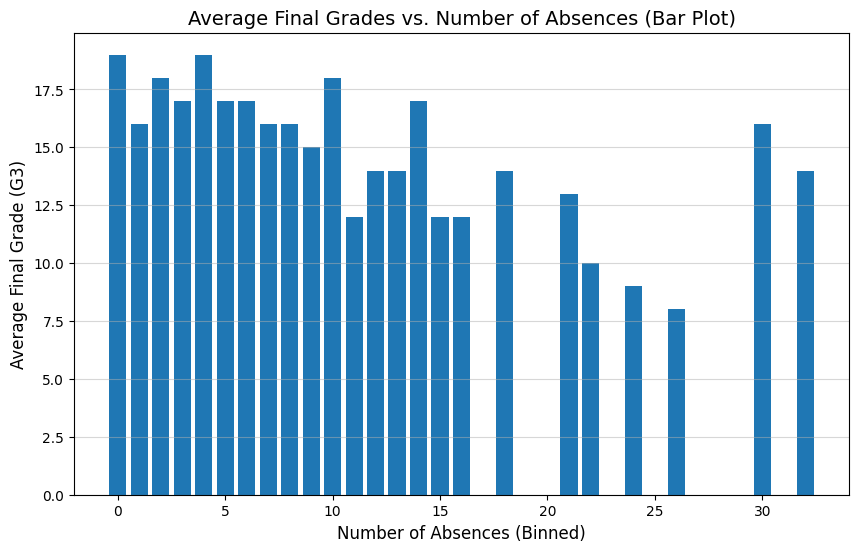

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Bar plot
plt.figure(figsize=(10, 6))
plt.bar(data['absences'],data['G3'])
plt.title("Average Final Grades vs. Number of Absences (Bar Plot)", fontsize=14)
plt.xlabel("Number of Absences (Binned)", fontsize=12)
plt.ylabel("Average Final Grade (G3)", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.5)
plt.show()


If we consider the two values above 30 outliers, then there is a clear negative correlation: more absences means more likely to have lower grade.

<Figure size 800x600 with 0 Axes>

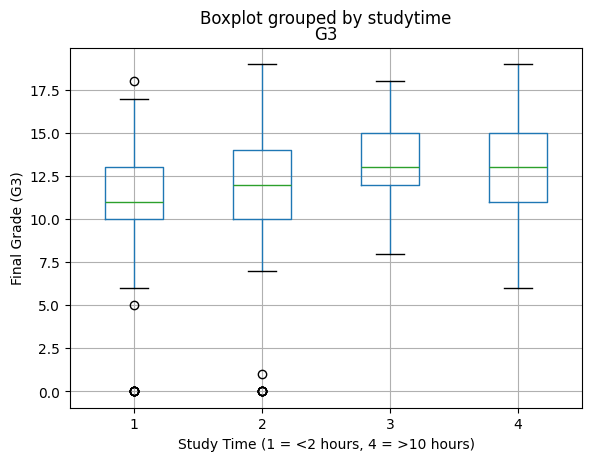

In [ ]:
plt.figure(figsize=(8, 6))
df.boxplot(column='G3',by='studytime')
plt.xlabel('Study Time (1 = <2 hours, 4 = >10 hours)')
plt.ylabel('Final Grade (G3)')
plt.show()

Students who study longer tend to achieve higher grades, as indicated by a positive trend in the median and quartile ranges. However, there are notable outliers, particularly among students with lower study time.

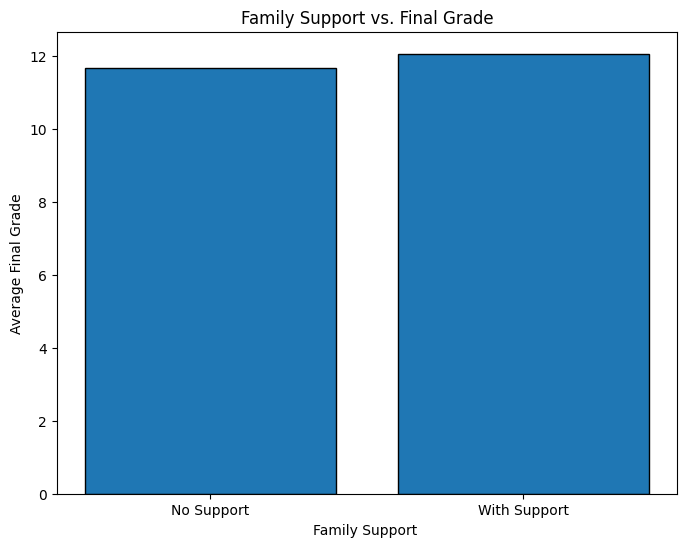

In [ ]:
family_avg = df.groupby('famsup_yes')['G3'].mean()

plt.figure(figsize=(8, 6))
plt.bar(family_avg.index, family_avg, edgecolor='black')
plt.title('Family Support vs. Final Grade')
plt.xlabel('Family Support ')
plt.ylabel('Average Final Grade')
plt.xticks(ticks=[0, 1], labels=['No Support', 'With Support'])
plt.show()


This bar chart compares the average final grades of students with and without family support. Although it shows there is a slightly higher average with support, this is very minimal so we can conclude that there is basically no effect.



<Figure size 800x600 with 0 Axes>

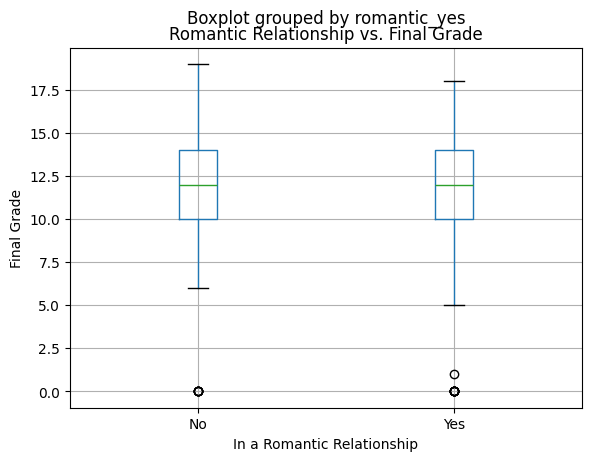

In [ ]:
plt.figure(figsize=(8, 6))
df.boxplot(column='G3', by='romantic_yes')
plt.title('Romantic Relationship vs. Final Grade')
plt.xlabel('In a Romantic Relationship')
plt.ylabel('Final Grade')
plt.xticks(ticks=[1, 2], labels=['No', 'Yes'])
plt.show()


This box plot is to show if there is an influence of romantic relationships on final grade. NO romantic relationship seems to have a slighly bigger median, but all the key stats(med,IQR, range) seem to be the same. This may suggest that romantic relationships can barely/not impact academic focus.

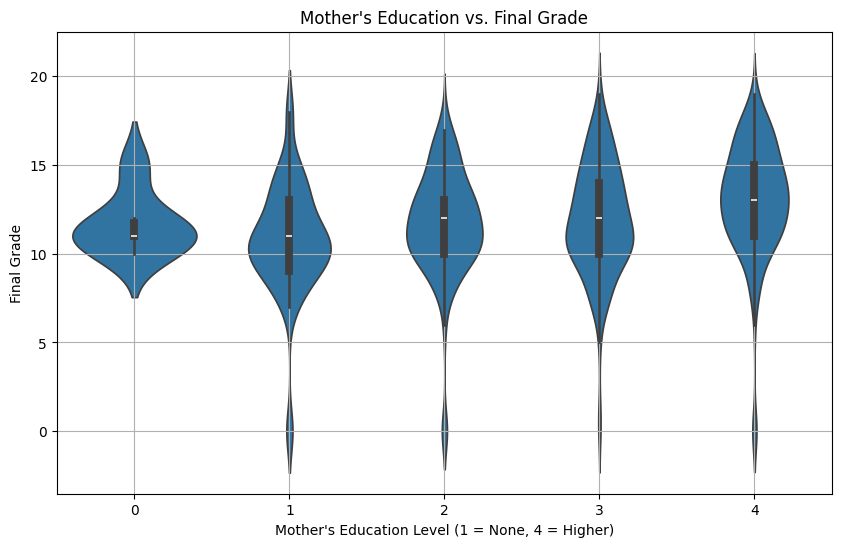

In [ ]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.violinplot(x='Medu', y='G3', data=df)
plt.title("Mother's Education vs. Final Grade")
plt.xlabel("Mother's Education Level (1 = None, 4 = Higher)")
plt.ylabel('Final Grade')
plt.grid()
plt.show()


This is to see if mothers education effects the childs education as well. Higher education levels for mothers are associated with better student performance, as evident from the concentration of higher grades at Medu = 4.

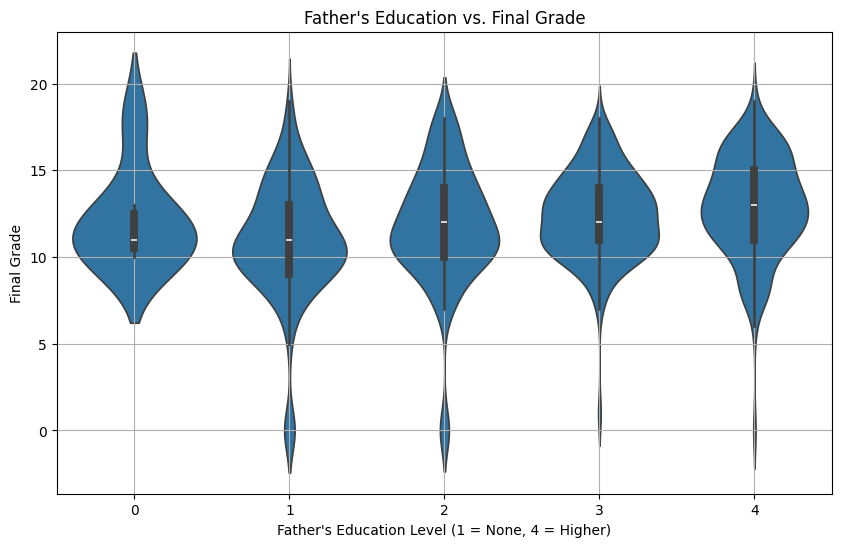

In [ ]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.violinplot(x='Fedu', y='G3', data=data)
plt.title("Father's Education vs. Final Grade")
plt.xlabel("Father's Education Level (1 = None, 4 = Higher)")
plt.ylabel('Final Grade')
plt.grid()
plt.show()

Father education level does not see the same effect as mother. There is equal concentration of grades regardless of the education level. Overall conclusion: parent education doesn't affect student performance. Looking at the mother data without looking at father data might lead to misinterpretation.





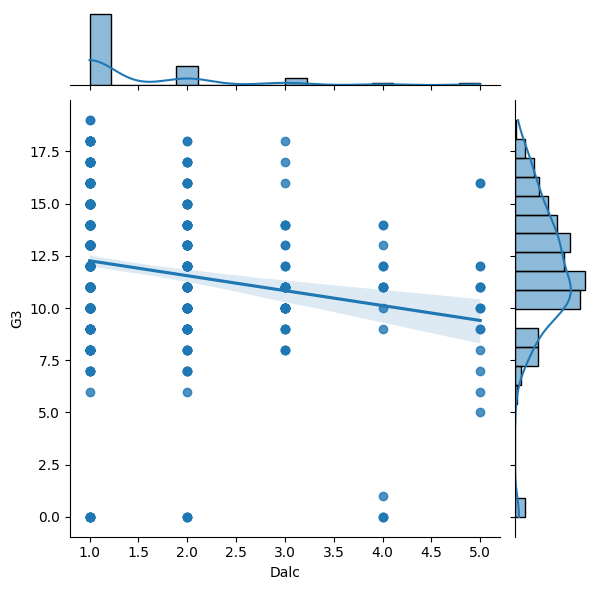

In [ ]:
sns.jointplot(x='Dalc', y='G3', data=data, kind='reg')
plt.show()

This highlights a negative trend that increased drinking adversely affects a students academic performance. There is also with a clustering of low G3 values at higher Dalc levels.

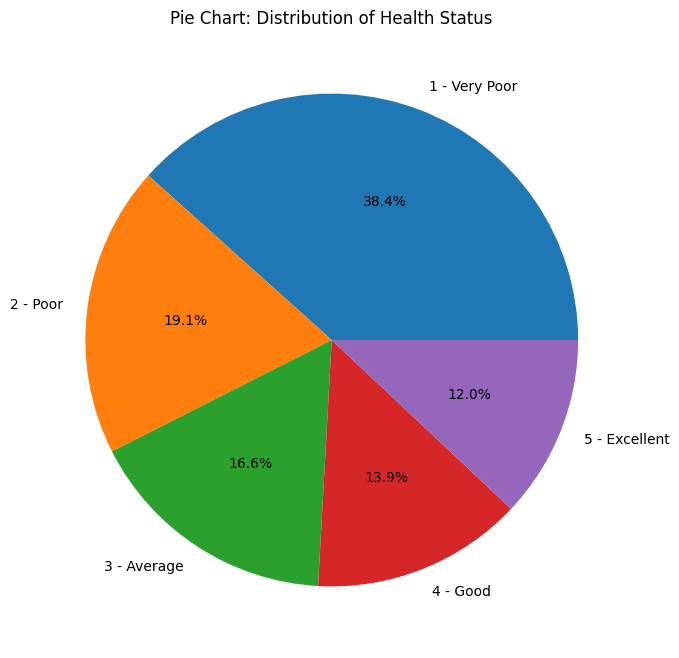

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie(data['health'].value_counts(), labels=['1 - Very Poor', '2 - Poor', '3 - Average', '4 - Good', '5 - Excellent'], autopct='%1.1f%%')
plt.title('Distribution of Health Status')
plt.show()

This pie chart shows that most students in the data set are poor. Other than that, this really tells us nothing, which is why pie charts are really bad. So we should use something else that can give us a better conclusion

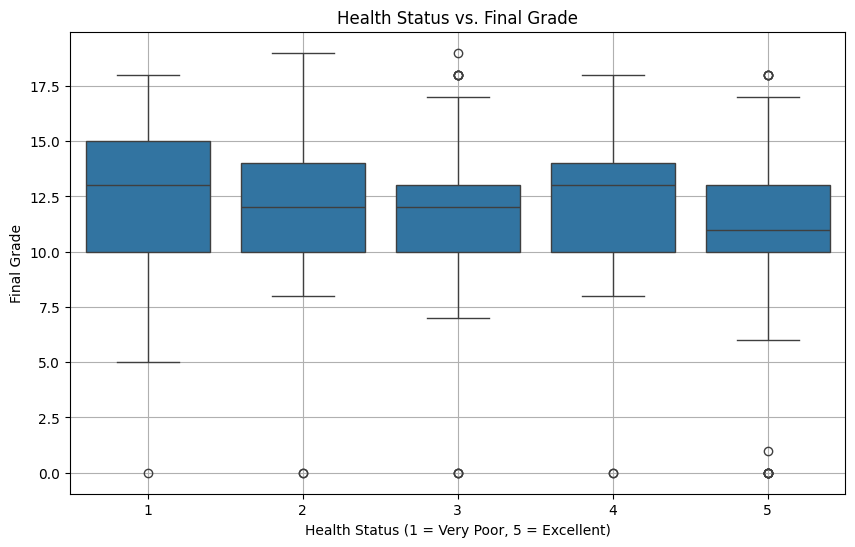

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='health', y='G3', data=data)
plt.title('Health Status vs. Final Grade')
plt.xlabel('Health Status (1 = Very Poor, 5 = Excellent)')
plt.ylabel('Final Grade')
plt.grid()
plt.show()


It seems thats poor health has a higher median. However, there is a wide range for that so it might not be accurate. Based on this graph, its reasonable to conlcude that health doesn't affect grade. I initially thought it would because if you have health problems, it might hinder your abuluty to learn.

In [ ]:
sns.pairplot(data = data)

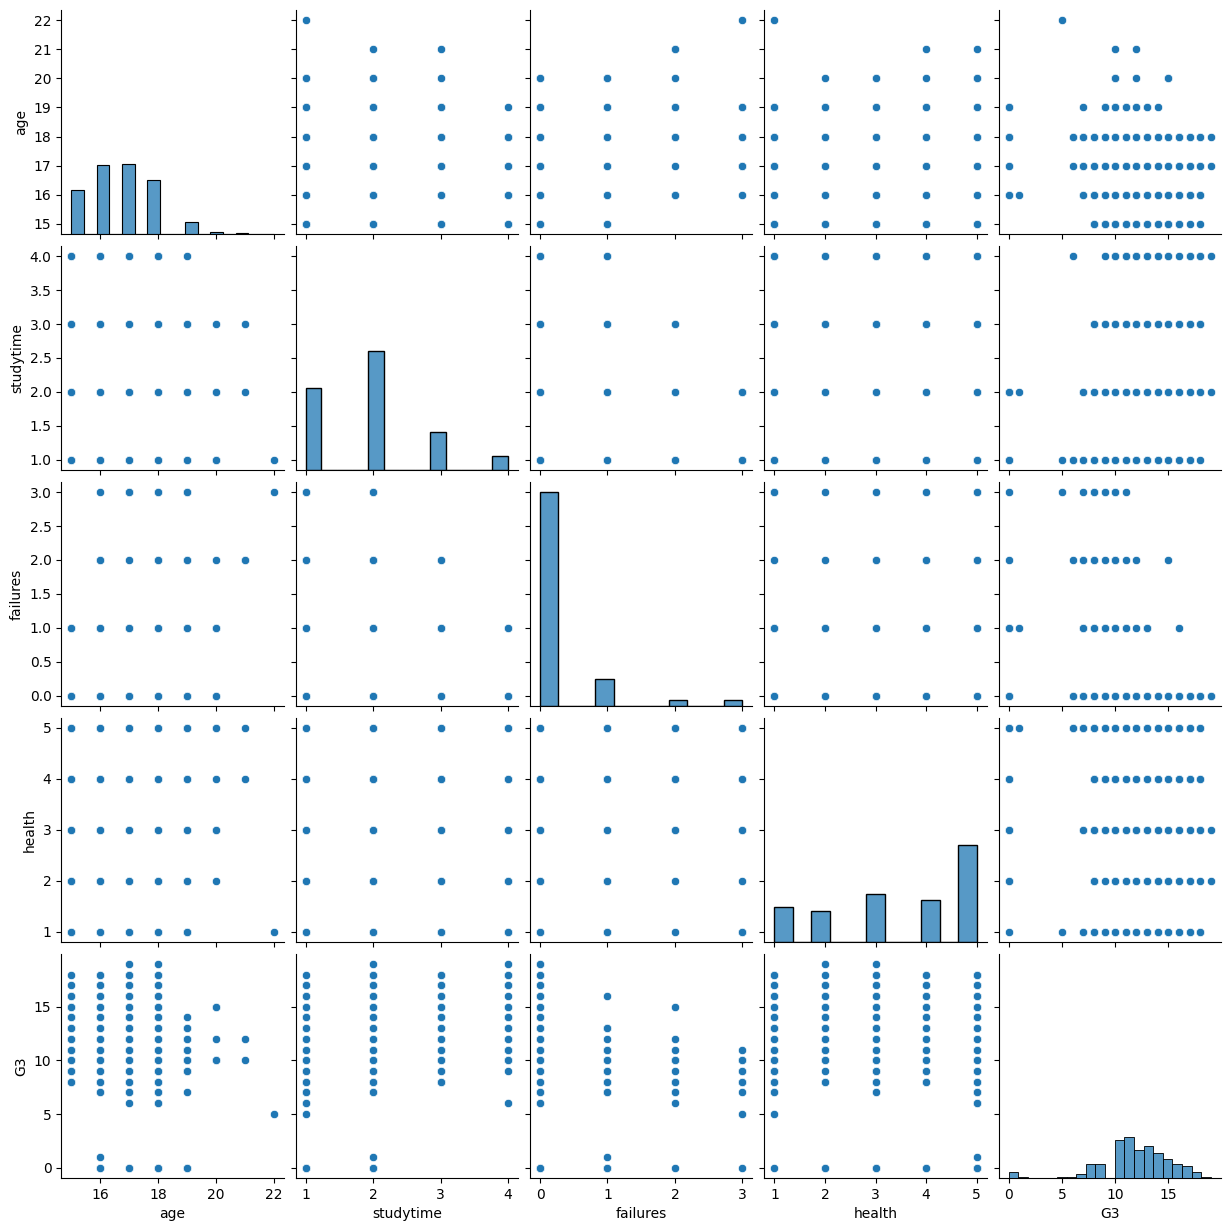

In [ ]:
sns.pairplot(data = data[['age', 'studytime', 'failures', 'health', 'G3']])



In [ ]:
data['paid_yes'].value_counts

<bound method IndexOpsMixin.value_counts of 0      False
1      False
2      False
3      False
4      False
       ...  
644    False
645    False
646    False
647    False
648    False
Name: paid_yes, Length: 649, dtype: bool>